In [1]:
"""
Módulo de Treinamento: VGG16, VGG19 e Xception
Classificação de Leucemia (ALL vs HEM)
Correção aplicada: Prioriza F1-Score no salvamento de modelos
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
from tqdm import tqdm
import pickle
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
warnings.filterwarnings('ignore')
from config import *

In [2]:
# ======================== CONFIGURAÇÕES ========================
# Diretórios
SAVE_DIR = 'models/vgg_xception'

# Hiperparâmetros
IMAGE_SIZE = 224  # VGG e Xception usam 224x224
BATCH_SIZE = 16   # Reduzido devido ao tamanho dos modelos
NUM_CLASSES = 2

LEARNING_RATE = 1e-4
NUM_WORKERS = 4
SEED = 42

# Configuração do dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# Criar diretórios
os.makedirs(SAVE_DIR, exist_ok=True)

Dispositivo: cuda


In [3]:
# ======================== DATASET ========================
class LeukemiaDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Carregar imagens ALL (classe 1)
        all_dir = os.path.join(data_dir, 'all')
        if os.path.exists(all_dir):
            for img_name in os.listdir(all_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.images.append(os.path.join(all_dir, img_name))
                    self.labels.append(1)
        
        # Carregar imagens HEM (classe 0)
        hem_dir = os.path.join(data_dir, 'hem')
        if os.path.exists(hem_dir):
            for img_name in os.listdir(hem_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.images.append(os.path.join(hem_dir, img_name))
                    self.labels.append(0)
        
        print(f"Dataset {data_dir}: {len(self.images)} imagens")
        print(f"  - ALL: {self.labels.count(1)} | HEM: {self.labels.count(0)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Erro ao carregar {img_path}: {e}")
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [4]:
# ======================== TRANSFORMAÇÕES ========================
def get_transforms():
    """Define transformações para treino e validação"""
    
    # Normalização específica para modelos pré-treinados no ImageNet
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE + 20, IMAGE_SIZE + 20)),
        transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1)
        ),
        transforms.ToTensor(),
        normalize
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        normalize
    ])
    
    return train_transform, val_transform

In [5]:
# ======================== ATTENTION MODULE ========================
class ChannelAttention(nn.Module):
    """Módulo de atenção por canal (Squeeze-and-Excitation)"""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        
        # Average pooling path
        avg_out = self.avg_pool(x).view(b, c)
        avg_out = self.fc(avg_out).view(b, c, 1, 1)
        
        # Max pooling path
        max_out = self.max_pool(x).view(b, c)
        max_out = self.fc(max_out).view(b, c, 1, 1)
        
        # Combine and apply sigmoid
        out = self.sigmoid(avg_out + max_out)
        return x * out.expand_as(x)

In [6]:
# ======================== MODELOS CUSTOMIZADOS ========================
class CustomVGG(nn.Module):
    """VGG16/19 customizado com attention e classificador robusto"""
    def __init__(self, model_type='vgg16', num_classes=2, dropout_rate=0.5):
        super().__init__()
        
        # Carregar modelo pré-treinado
        if model_type == 'vgg16':
            self.base_model = models.vgg16(pretrained=True)
        else:  # vgg19
            self.base_model = models.vgg19(pretrained=True)
        
        # Extrair features (sem o classificador)
        self.features = self.base_model.features
        
        # Adicionar attention após as features
        self.attention = ChannelAttention(512, reduction=16)
        
        # Pool adaptativo
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        # Classificador customizado
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout_rate * 0.8),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(256, num_classes)
        )
        
        # Inicializar pesos do classificador
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

class CustomXception(nn.Module):
    """Xception customizado com attention e classificador robusto"""
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super().__init__()
        
        # Nota: Xception requer instalação do timm
        # pip install timm
        try:
            import timm
            self.base_model = timm.create_model('xception', pretrained=True, features_only=True)
            self.use_timm = True
        except:
            print("timm não instalado. Usando implementação alternativa.")
            # Implementação alternativa usando ResNet como base
            self.base_model = models.resnet50(pretrained=True)
            self.features = nn.Sequential(*list(self.base_model.children())[:-2])
            self.use_timm = False
        
        # Dimensão de saída das features
        if self.use_timm:
            feature_dim = 2048
        else:
            feature_dim = 2048  # ResNet50
        
        # Attention module
        self.attention = ChannelAttention(feature_dim, reduction=16)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Classificador
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate * 0.8),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, num_classes)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        if self.use_timm:
            features = self.base_model(x)[-1]  # Última camada de features
        else:
            features = self.features(x)
        
        features = self.attention(features)
        features = self.global_pool(features).flatten(1)
        output = self.classifier(features)
        return output

In [7]:
# ======================== FOCAL LOSS ========================
class FocalLoss(nn.Module):
    """Focal Loss para lidar com desbalanceamento de classes"""
    def __init__(self, alpha=0.25, gamma=2.0, num_classes=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        # Aplicar alpha para balanceamento
        targets_one_hot = F.one_hot(targets, self.num_classes).float()
        alpha_t = self.alpha * targets_one_hot[:, 1] + (1 - self.alpha) * targets_one_hot[:, 0]
        
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [8]:
# ======================== MIXUP AUGMENTATION ========================
def mixup_data(x, y, alpha=0.2):
    """Aplica mixup aos dados para melhor generalização"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calcula loss com mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


In [9]:
# ======================== TREINAMENTO ========================
def train_epoch(model, loader, criterion, optimizer, scaler, device, use_mixup=True):
    """Treina o modelo por uma época"""
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    progress_bar = tqdm(loader, desc='Training', leave=False)
    for inputs, targets in progress_bar:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Aplicar mixup com probabilidade
        if use_mixup and np.random.random() > 0.5:
            inputs, targets_a, targets_b, lam = mixup_data(inputs, targets, alpha=0.2)
            mixed = True
        else:
            mixed = False
        
        optimizer.zero_grad()
        
        # Forward pass com mixed precision
        if scaler is not None:
            with autocast():
                outputs = model(inputs)
                if mixed:
                    loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
                else:
                    loss = criterion(outputs, targets)
        else:
            outputs = model(inputs)
            if mixed:
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                loss = criterion(outputs, targets)
        
        # Backward pass
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Métricas
        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        
        if not mixed:
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
        
        # Atualizar barra de progresso
        progress_bar.set_postfix({'loss': loss.item()})
    
    # Calcular métricas
    avg_loss = total_loss / len(loader.dataset)
    if len(all_targets) > 0:
        acc = accuracy_score(all_targets, all_preds)
        f1 = f1_score(all_targets, all_preds, average='weighted')
    else:
        acc = f1 = 0.0
    
    return avg_loss, acc, f1

def validate(model, loader, criterion, device):
    """Valida o modelo"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc='Validation', leave=False):
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return avg_loss, acc, f1, all_targets, all_preds


In [10]:
# ======================== VISUALIZAÇÃO ========================
def plot_training_curves(history, model_name, save_dir):
    """Plota curvas de treinamento e validação"""
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Cores
    train_color = '#FF6B6B'
    val_color = '#4ECDC4'
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], color=train_color, 
                    linewidth=2, label='Train', marker='o', markersize=3, markevery=5)
    axes[0, 0].plot(epochs, history['val_loss'], color=val_color,
                    linewidth=2, label='Validation', marker='s', markersize=3, markevery=5)
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(epochs, history['train_acc'], color=train_color,
                    linewidth=2, label='Train', marker='o', markersize=3, markevery=5)
    axes[0, 1].plot(epochs, history['val_acc'], color=val_color,
                    linewidth=2, label='Validation', marker='s', markersize=3, markevery=5)
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0.7, 1.0])
    
    # F1-Score
    axes[1, 0].plot(epochs, history['train_f1'], color=train_color,
                    linewidth=2, label='Train', marker='o', markersize=3, markevery=5)
    axes[1, 0].plot(epochs, history['val_f1'], color=val_color,
                    linewidth=2, label='Validation', marker='s', markersize=3, markevery=5)
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_title('Training and Validation F1-Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0.7, 1.0])
    
    # Learning Rate
    if 'lr' in history:
        axes[1, 1].plot(epochs, history['lr'], color='#95E77E', linewidth=2)
        axes[1, 1].set_xlabel('Epochs')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_title('Learning Rate Schedule')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_yscale('log')
    
    plt.suptitle(f'{model_name} - Training Progress', fontsize=14, y=1.02)
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f'{model_name}_training_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"📊 Gráfico salvo em: {save_path}")

def plot_confusion_matrix(y_true, y_pred, model_name, save_dir):
    """Plota matriz de confusão"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['HEM', 'ALL'], 
                yticklabels=['HEM', 'ALL'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    save_path = os.path.join(save_dir, f'{model_name}_confusion_matrix.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"📊 Matriz de confusão salva em: {save_path}")


In [11]:
# ======================== EARLY STOPPING ========================
class EarlyStopping:
    """Early stopping para evitar overfitting"""
    def __init__(self, patience=15, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self.mode == 'max':
            if score <= self.best_score + self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0
        else:  # mode == 'min'
            if score >= self.best_score - self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0
        
        return self.early_stop

In [12]:
# ======================== FUNÇÃO PRINCIPAL DE TREINAMENTO ========================
def train_model(model_name: str) -> dict:
    """Treina um modelo específico e retorna métricas padronizadas."""
    print(f"\n{'='*60}")
    print(f"TREINANDO MODELO: {model_name.upper()}")
    print(f"{'='*60}")
    print(f"Início: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Configurar seed
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)

    # Preparar datasets
    train_transform, val_transform = get_transforms()
    train_dataset = LeukemiaDataset(TRAIN_DIR, train_transform)
    val_dataset = LeukemiaDataset(VAL_DIR, val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Criar modelo
    if model_name in ['vgg16', 'vgg19']:
        model = CustomVGG(model_type=model_name, num_classes=NUM_CLASSES, dropout_rate=0.5)
    elif model_name == 'xception':
        model = CustomXception(num_classes=NUM_CLASSES, dropout_rate=0.5)
    else:
        raise ValueError(f"Modelo {model_name} não suportado")

    model = model.to(DEVICE)

    # Contar parâmetros
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total de parâmetros: {total_params:,}")
    print(f"Parâmetros treináveis: {trainable_params:,}")

    # Loss e otimizador
    criterion = FocalLoss(alpha=0.25, gamma=2.0, num_classes=NUM_CLASSES)

    if hasattr(model, 'features') or hasattr(model, 'base_model'):
        if hasattr(model, 'features'):
            backbone_params = model.features.parameters()
        else:
            backbone_params = model.base_model.parameters()

        classifier_params = list(model.classifier.parameters())
        if hasattr(model, 'attention'):
            classifier_params += list(model.attention.parameters())

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': LEARNING_RATE * 0.1},
            {'params': classifier_params, 'lr': LEARNING_RATE}
        ], weight_decay=1e-5)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    # Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    # Mixed precision
    scaler = GradScaler() if DEVICE.type == 'cuda' else None

    # Early stopping
    early_stopping = EarlyStopping(patience=20, min_delta=0.001, mode='max')

    # Histórico
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': [],
        'lr': []
    }

    # Melhores métricas
    best_f1 = 0.0
    best_acc = 0.0
    best_epoch = 0
    model_path = None  # para retornarmos onde o melhor checkpoint foi salvo

    # Loop de treinamento
    for epoch in range(EPOCHS):
        print(f"\n📍 Epoch {epoch+1}/{EPOCHS}")

        # Treinar
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE, use_mixup=True
        )

        # Validar
        val_loss, val_acc, val_f1, val_targets, val_preds = validate(
            model, val_loader, criterion, DEVICE
        )

        # Atualizar scheduler (após validação mantém coerência com métricas)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Registrar métricas
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        # Gap
        gap = abs(float(train_f1) - float(val_f1))

        # Prints
        print(f"📊 Train -> Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"📊 Valid -> Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"📊 Gap: {gap:.4f} | LR: {current_lr:.6f}")

        # Melhor modelo (prioriza F1)
        if val_f1 > best_f1:
            best_f1 = float(val_f1)
            best_acc = float(val_acc)
            best_epoch = int(epoch + 1)

            checkpoint = {
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_f1': best_f1,
                'best_acc': best_acc,
                'val_loss': float(val_loss),
                'train_f1': float(train_f1),
                'val_f1': float(val_f1),
                'gap': float(gap),
                'history': history
            }

            model_path = os.path.join(SAVE_DIR, f'{model_name}_best.pt')
            torch.save(checkpoint, model_path)
            print(f"✅ Modelo salvo! F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Gap: {gap:.4f}")

            # Matriz de confusão apenas após aquecer
            if epoch > 10:
                plot_confusion_matrix(val_targets, val_preds, model_name, SAVE_DIR)

        # Early stopping
        if early_stopping(val_f1):
            print(f"⚠️ Early stopping ativado na época {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"TREINAMENTO CONCLUÍDO - {model_name.upper()}")
    print(f"Melhor F1-Score: {best_f1:.4f} (Época {best_epoch})")
    print(f"Melhor Accuracy: {best_acc:.4f}")
    print(f"{'='*60}")

    # Curvas
    plot_training_curves(history, model_name, SAVE_DIR)

    # Salvar histórico
    history_path = os.path.join(SAVE_DIR, f'{model_name}_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)
    print(f"📁 Histórico salvo em: {history_path}")

    # Limpar memória
    del model
    torch.cuda.empty_cache()

    # ✅ Retorno padronizado para evitar erros de formatação
    return {
        "f1": float(best_f1),
        "accuracy": float(best_acc),
        "best_epoch": int(best_epoch),
        "model_path": model_path if model_path is not None else ""
    }


Iniciando treinamento de modelos CNN...

TREINANDO MODELO: VGG16
Início: 2025-09-27 18:19:17
Dataset dataset/cnmc2019_splits/images/train: 11102 imagens
  - ALL: 5335 | HEM: 5767
Dataset dataset/cnmc2019_splits/images/val: 1172 imagens
  - ALL: 571 | HEM: 601
Total de parâmetros: 245,615,658
Parâmetros treináveis: 245,615,658

📍 Epoch 1/100


📊 Train -> Loss: 3.1320 | Acc: 0.6470 | F1: 0.6454
📊 Valid -> Loss: 1.8478 | Acc: 0.5794 | F1: 0.4909
📊 Gap: 0.1545 | LR: 0.000010
✅ Modelo salvo! F1: 0.4909 | Acc: 0.5794 | Gap: 0.1545

📍 Epoch 2/100


📊 Train -> Loss: 2.1870 | Acc: 0.6914 | F1: 0.6865
📊 Valid -> Loss: 1.3982 | Acc: 0.6442 | F1: 0.5985
📊 Gap: 0.0880 | LR: 0.000009
✅ Modelo salvo! F1: 0.5985 | Acc: 0.6442 | Gap: 0.0880

📍 Epoch 3/100


📊 Train -> Loss: 1.9100 | Acc: 0.7045 | F1: 0.6998
📊 Valid -> Loss: 1.6747 | Acc: 0.5648 | F1: 0.4613
📊 Gap: 0.2385 | LR: 0.000008

📍 Epoch 4/100


📊 Train -> Loss: 1.6563 | Acc: 0.7324 | F1: 0.7283
📊 Valid -> Loss: 1.1497 | Acc: 0.6766 | F1: 0.6423
📊 Gap: 0.0861 | LR: 0.000007
✅ Modelo salvo! F1: 0.6423 | Acc: 0.6766 | Gap: 0.0861

📍 Epoch 5/100


...

📊 Train -> Loss: 1.0421 | Acc: 0.7694 | F1: 0.7674
📊 Valid -> Loss: 1.0029 | Acc: 0.5947 | F1: 0.5087
📊 Gap: 0.2587 | LR: 0.000010

📍 Epoch 11/100


📊 Train -> Loss: 1.1344 | Acc: 0.7510 | F1: 0.7481
📊 Valid -> Loss: 0.4856 | Acc: 0.7022 | F1: 0.6729
📊 Gap: 0.0752 | LR: 0.000010
✅ Modelo salvo! F1: 0.6729 | Acc: 0.7022 | Gap: 0.0752

📍 Epoch 12/100


📊 Train -> Loss: 1.0614 | Acc: 0.7533 | F1: 0.7508
📊 Valid -> Loss: 1.0125 | Acc: 0.5631 | F1: 0.4509
📊 Gap: 0.2999 | LR: 0.000010

📍 Epoch 13/100


📊 Train -> Loss: 0.9702 | Acc: 0.7456 | F1: 0.7426
📊 Valid -> Loss: 0.6898 | Acc: 0.6288 | F1: 0.5646
📊 Gap: 0.1779 | LR: 0.000010

📍 Epoch 14/100


📊 Train -> Loss: 0.8223 | Acc: 0.7751 | F1: 0.7729
📊 Valid -> Loss: 0.4290 | Acc: 0.7295 | F1: 0.7096
📊 Gap: 0.0633 | LR: 0.000009
✅ Modelo salvo! F1: 0.7096 | Acc: 0.7295 | Gap: 0.0633


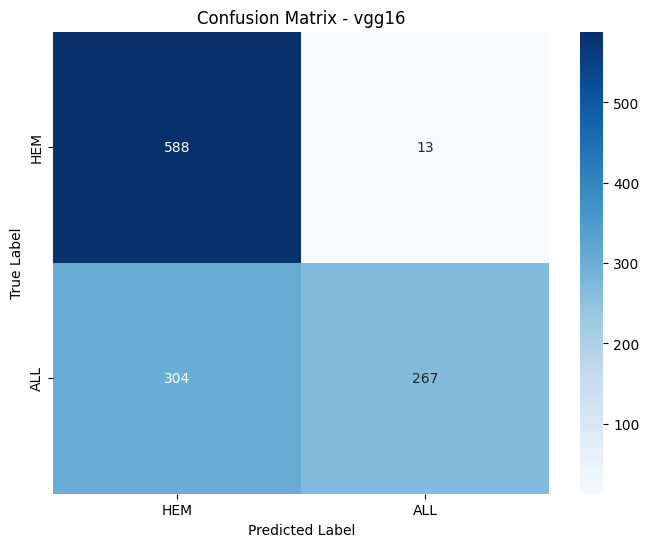

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 15/100


📊 Train -> Loss: 0.7700 | Acc: 0.7705 | F1: 0.7681
📊 Valid -> Loss: 0.3799 | Acc: 0.6877 | F1: 0.6522
📊 Gap: 0.1158 | LR: 0.000009

📍 Epoch 16/100


📊 Train -> Loss: 0.7253 | Acc: 0.7722 | F1: 0.7700
📊 Valid -> Loss: 0.5902 | Acc: 0.6067 | F1: 0.5288
📊 Gap: 0.2411 | LR: 0.000008

📍 Epoch 17/100


📊 Train -> Loss: 0.6514 | Acc: 0.7958 | F1: 0.7945
📊 Valid -> Loss: 0.4358 | Acc: 0.6672 | F1: 0.6247
📊 Gap: 0.1698 | LR: 0.000008

📍 Epoch 18/100


📊 Train -> Loss: 0.6015 | Acc: 0.8086 | F1: 0.8074
📊 Valid -> Loss: 0.2017 | Acc: 0.7739 | F1: 0.7631
📊 Gap: 0.0443 | LR: 0.000007
✅ Modelo salvo! F1: 0.7631 | Acc: 0.7739 | Gap: 0.0443


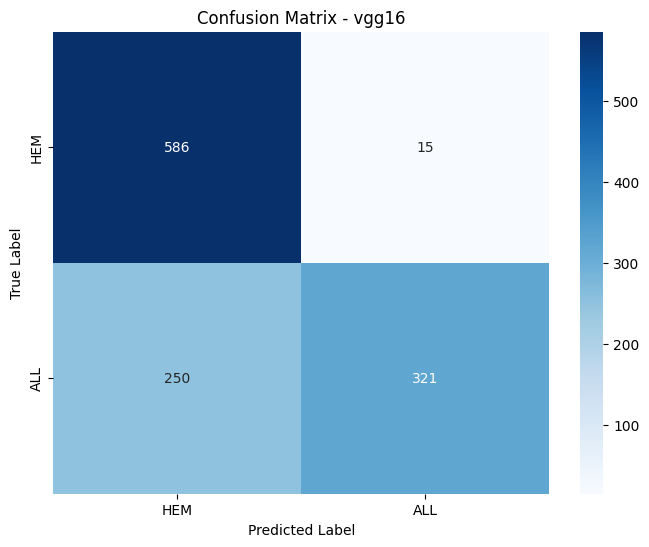

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 19/100


📊 Train -> Loss: 0.5944 | Acc: 0.8017 | F1: 0.8002
📊 Valid -> Loss: 0.2751 | Acc: 0.7671 | F1: 0.7535
📊 Gap: 0.0467 | LR: 0.000006

📍 Epoch 20/100


📊 Train -> Loss: 0.5316 | Acc: 0.8238 | F1: 0.8229
📊 Valid -> Loss: 0.2823 | Acc: 0.7500 | F1: 0.7324
📊 Gap: 0.0905 | LR: 0.000005

📍 Epoch 21/100


📊 Train -> Loss: 0.5140 | Acc: 0.8217 | F1: 0.8206
📊 Valid -> Loss: 0.2068 | Acc: 0.8055 | F1: 0.7996
📊 Gap: 0.0211 | LR: 0.000005
✅ Modelo salvo! F1: 0.7996 | Acc: 0.8055 | Gap: 0.0211


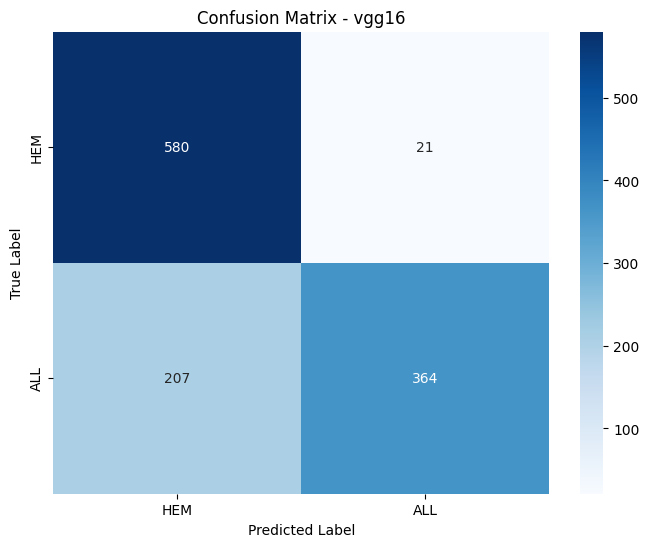

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 22/100


📊 Train -> Loss: 0.4771 | Acc: 0.8215 | F1: 0.8206
📊 Valid -> Loss: 0.1459 | Acc: 0.8353 | F1: 0.8320
📊 Gap: 0.0114 | LR: 0.000004
✅ Modelo salvo! F1: 0.8320 | Acc: 0.8353 | Gap: 0.0114


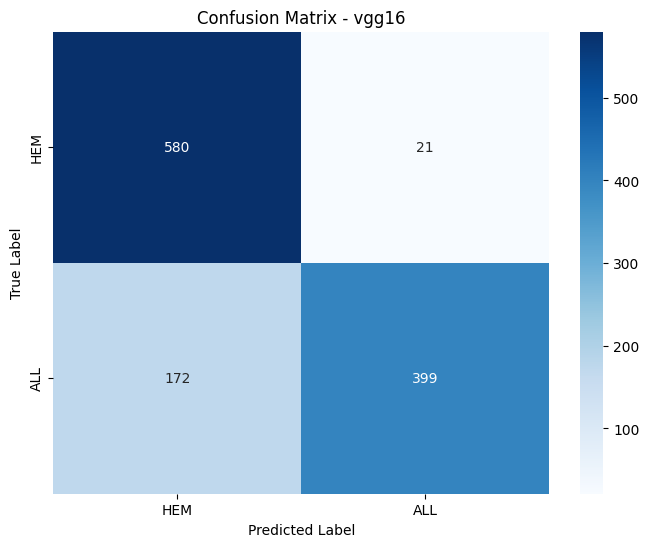

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 23/100


📊 Train -> Loss: 0.4652 | Acc: 0.8255 | F1: 0.8247
📊 Valid -> Loss: 0.1643 | Acc: 0.8268 | F1: 0.8221
📊 Gap: 0.0025 | LR: 0.000003

📍 Epoch 24/100


📊 Train -> Loss: 0.4624 | Acc: 0.8392 | F1: 0.8386
📊 Valid -> Loss: 0.2099 | Acc: 0.7995 | F1: 0.7917
📊 Gap: 0.0468 | LR: 0.000003

📍 Epoch 25/100


📊 Train -> Loss: 0.4256 | Acc: 0.8379 | F1: 0.8375
📊 Valid -> Loss: 0.2007 | Acc: 0.7944 | F1: 0.7858
📊 Gap: 0.0517 | LR: 0.000002

📍 Epoch 26/100


📊 Train -> Loss: 0.4416 | Acc: 0.8319 | F1: 0.8309
📊 Valid -> Loss: 0.2054 | Acc: 0.7910 | F1: 0.7819
📊 Gap: 0.0489 | LR: 0.000002

📍 Epoch 27/100


📊 Train -> Loss: 0.4581 | Acc: 0.8387 | F1: 0.8380
📊 Valid -> Loss: 0.1776 | Acc: 0.8166 | F1: 0.8111
📊 Gap: 0.0270 | LR: 0.000001

📍 Epoch 28/100


📊 Train -> Loss: 0.4307 | Acc: 0.8461 | F1: 0.8455
📊 Valid -> Loss: 0.1498 | Acc: 0.8362 | F1: 0.8326
📊 Gap: 0.0129 | LR: 0.000001
✅ Modelo salvo! F1: 0.8326 | Acc: 0.8362 | Gap: 0.0129


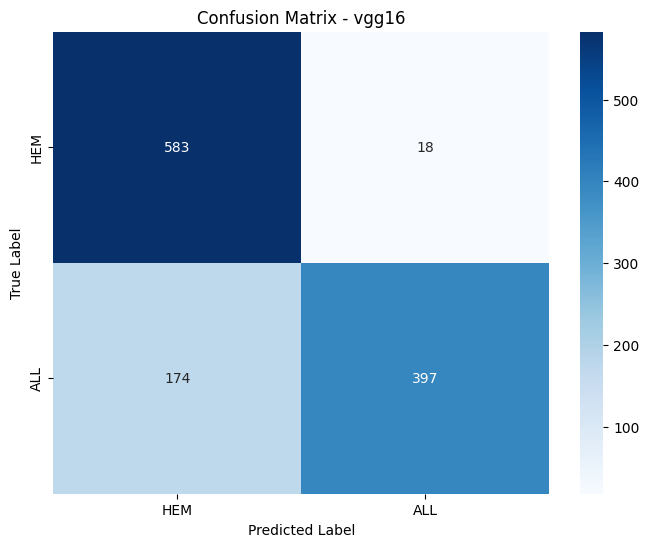

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 29/100


📊 Train -> Loss: 0.4307 | Acc: 0.8435 | F1: 0.8430
📊 Valid -> Loss: 0.1564 | Acc: 0.8328 | F1: 0.8290
📊 Gap: 0.0141 | LR: 0.000001

📍 Epoch 30/100


📊 Train -> Loss: 0.4148 | Acc: 0.8478 | F1: 0.8473
📊 Valid -> Loss: 0.1336 | Acc: 0.8490 | F1: 0.8463
📊 Gap: 0.0010 | LR: 0.000010
✅ Modelo salvo! F1: 0.8463 | Acc: 0.8490 | Gap: 0.0010


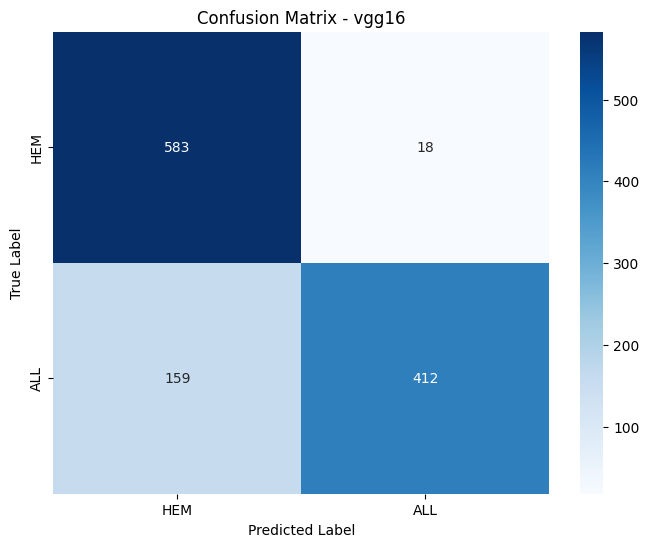

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 31/100


📊 Train -> Loss: 0.4760 | Acc: 0.8296 | F1: 0.8289
📊 Valid -> Loss: 0.1594 | Acc: 0.7773 | F1: 0.7659
📊 Gap: 0.0630 | LR: 0.000010

📍 Epoch 32/100


📊 Train -> Loss: 0.4666 | Acc: 0.8129 | F1: 0.8118
📊 Valid -> Loss: 0.1617 | Acc: 0.7807 | F1: 0.7688
📊 Gap: 0.0430 | LR: 0.000010

📍 Epoch 33/100


📊 Train -> Loss: 0.4352 | Acc: 0.8270 | F1: 0.8263
📊 Valid -> Loss: 0.0699 | Acc: 0.8695 | F1: 0.8683
📊 Gap: 0.0420 | LR: 0.000010
✅ Modelo salvo! F1: 0.8683 | Acc: 0.8695 | Gap: 0.0420


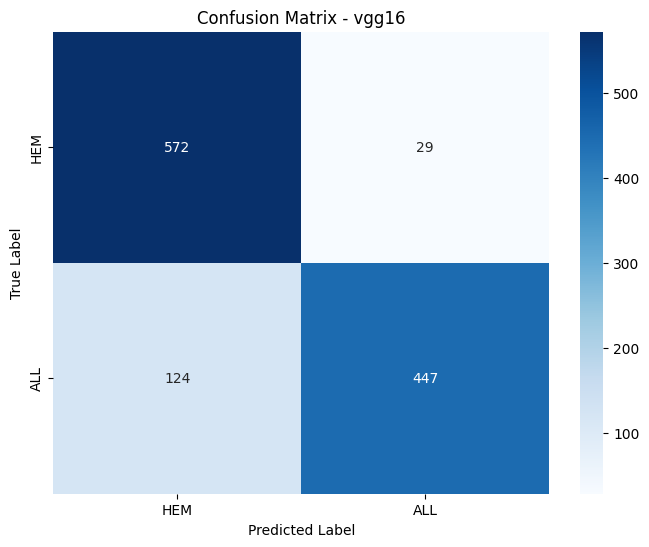

📊 Matriz de confusão salva em: models/vgg_xception/vgg16_confusion_matrix.png

📍 Epoch 34/100


📊 Train -> Loss: nan | Acc: 0.7947 | F1: 0.7914
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.4438 | LR: 0.000010

📍 Epoch 35/100


📊 Train -> Loss: nan | Acc: 0.6666 | F1: 0.6318
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.2842 | LR: 0.000010

📍 Epoch 36/100


📊 Train -> Loss: nan | Acc: 0.5220 | F1: 0.3580
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0104 | LR: 0.000010

📍 Epoch 37/100


📊 Train -> Loss: nan | Acc: 0.5233 | F1: 0.3595
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0118 | LR: 0.000009

📍 Epoch 38/100


...

📊 Train -> Loss: nan | Acc: 0.5178 | F1: 0.3533
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0057 | LR: 0.000006

📍 Epoch 50/100


📊 Train -> Loss: nan | Acc: 0.5213 | F1: 0.3573
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0096 | LR: 0.000005

📍 Epoch 51/100


📊 Train -> Loss: nan | Acc: 0.5271 | F1: 0.3638
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0162 | LR: 0.000005

📍 Epoch 52/100


📊 Train -> Loss: nan | Acc: 0.5199 | F1: 0.3557
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0080 | LR: 0.000005

📍 Epoch 53/100


📊 Train -> Loss: nan | Acc: 0.5206 | F1: 0.3565
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0088 | LR: 0.000004
⚠️ Early stopping ativado na época 53

TREINAMENTO CONCLUÍDO - VGG16
Melhor F1-Score: 0.8683 (Época 33)
Melhor Accuracy: 0.8695


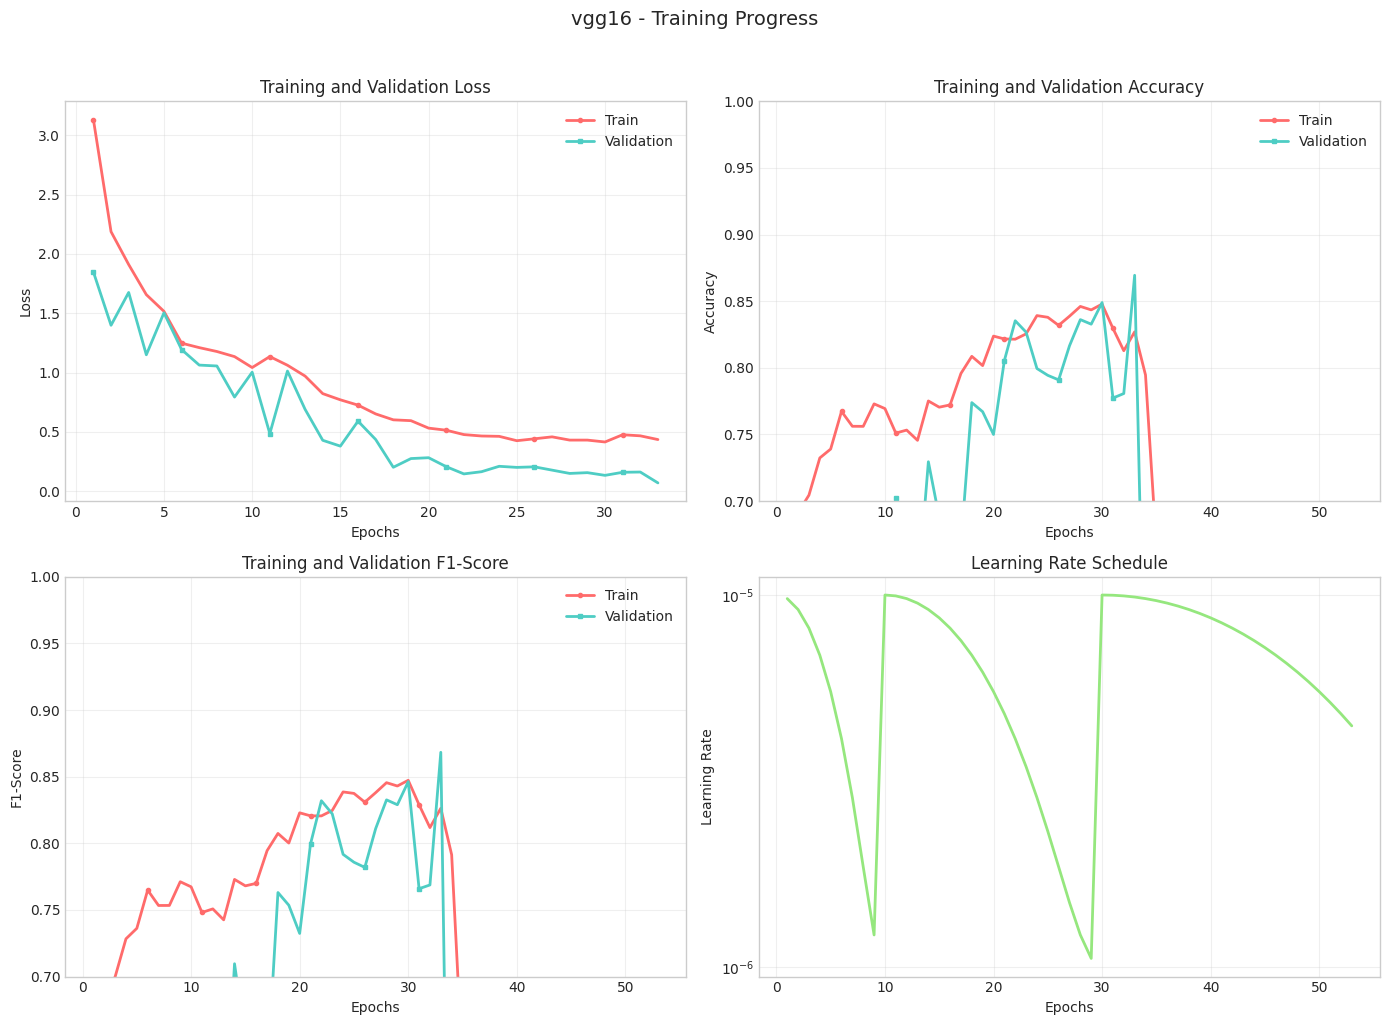

📊 Gráfico salvo em: models/vgg_xception/vgg16_training_curves.png
📁 Histórico salvo em: models/vgg_xception/vgg16_history.pkl

TREINANDO MODELO: VGG19
Início: 2025-09-27 19:55:07
Dataset dataset/cnmc2019_splits/images/train: 11102 imagens
  - ALL: 5335 | HEM: 5767
Dataset dataset/cnmc2019_splits/images/val: 1172 imagens
  - ALL: 571 | HEM: 601
Total de parâmetros: 250,925,354
Parâmetros treináveis: 250,925,354

📍 Epoch 1/100


📊 Train -> Loss: 3.2472 | Acc: 0.6817 | F1: 0.6797
📊 Valid -> Loss: 3.7391 | Acc: 0.5299 | F1: 0.3912
📊 Gap: 0.2885 | LR: 0.000010
✅ Modelo salvo! F1: 0.3912 | Acc: 0.5299 | Gap: 0.2885

📍 Epoch 2/100


📊 Train -> Loss: 2.3131 | Acc: 0.7164 | F1: 0.7115
📊 Valid -> Loss: 2.1960 | Acc: 0.5887 | F1: 0.5001
📊 Gap: 0.2114 | LR: 0.000009
✅ Modelo salvo! F1: 0.5001 | Acc: 0.5887 | Gap: 0.2114

📍 Epoch 3/100


📊 Train -> Loss: 1.9367 | Acc: 0.7318 | F1: 0.7282
📊 Valid -> Loss: 2.6681 | Acc: 0.5341 | F1: 0.3935
📊 Gap: 0.3347 | LR: 0.000008

📍 Epoch 4/100


📊 Train -> Loss: 1.7288 | Acc: 0.7397 | F1: 0.7364
📊 Valid -> Loss: 1.7010 | Acc: 0.5828 | F1: 0.4869
📊 Gap: 0.2495 | LR: 0.000007

📍 Epoch 5/100


...

📊 Train -> Loss: nan | Acc: 0.7160 | F1: 0.7096
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.3620 | LR: 0.000007

📍 Epoch 19/100


📊 Train -> Loss: nan | Acc: 0.6333 | F1: 0.6082
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.2605 | LR: 0.000006

📍 Epoch 20/100


📊 Train -> Loss: nan | Acc: 0.5214 | F1: 0.3574
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0097 | LR: 0.000005

📍 Epoch 21/100


📊 Train -> Loss: nan | Acc: 0.5168 | F1: 0.3522
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0046 | LR: 0.000005

📍 Epoch 22/100


📊 Train -> Loss: nan | Acc: 0.5192 | F1: 0.3549
📊 Valid -> Loss: nan | Acc: 0.5128 | F1: 0.3477
📊 Gap: 0.0073 | LR: 0.000004
⚠️ Early stopping ativado na época 22

TREINAMENTO CONCLUÍDO - VGG19
Melhor F1-Score: 0.5001 (Época 2)
Melhor Accuracy: 0.5887


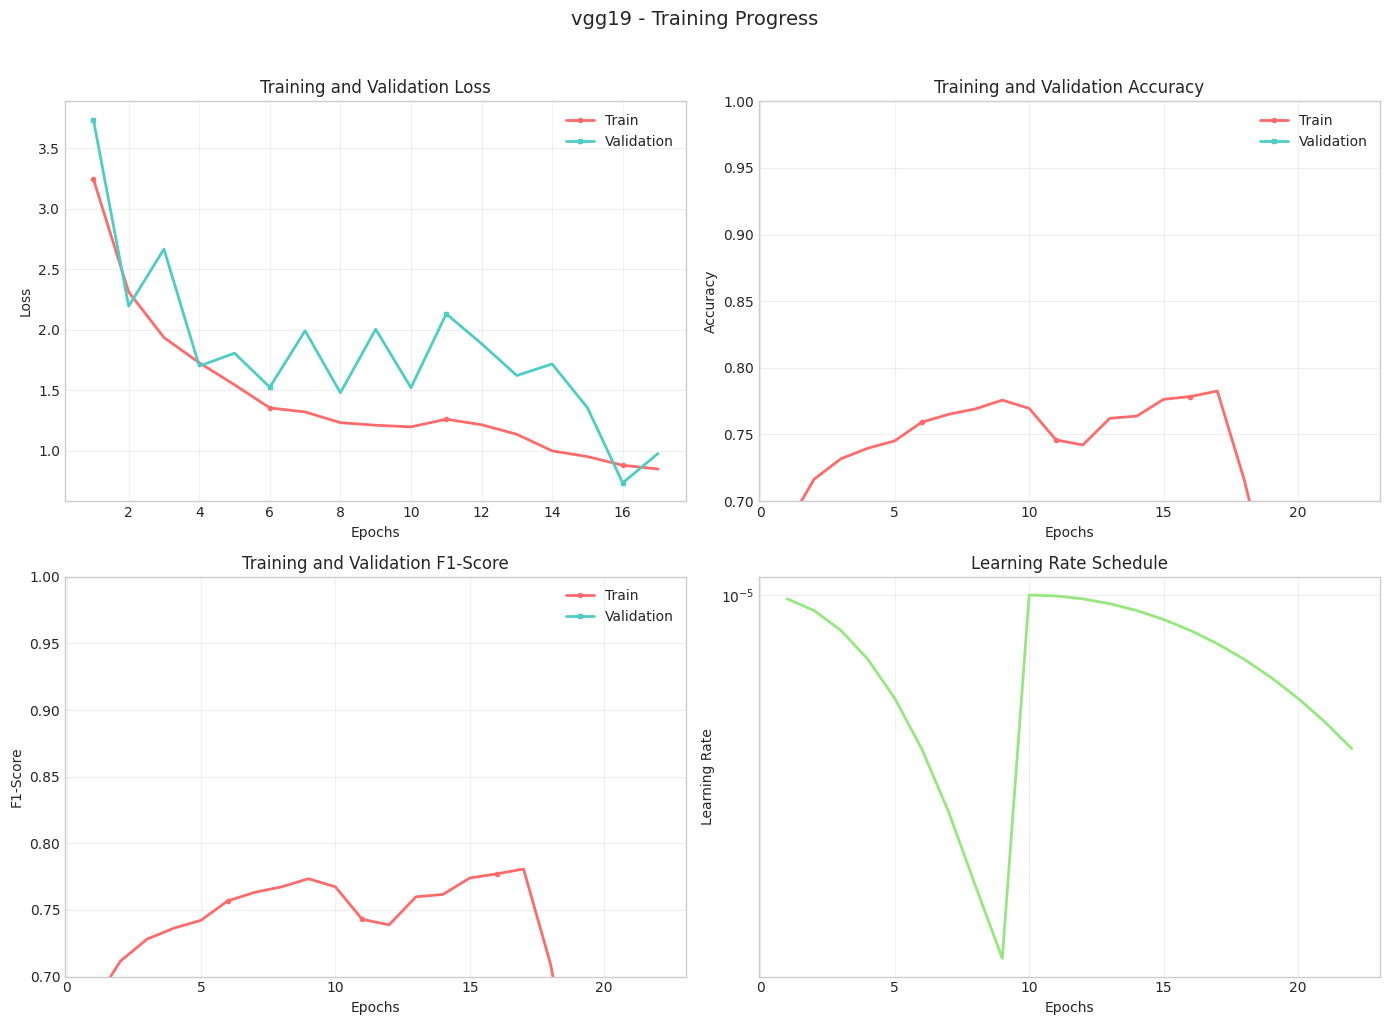

📊 Gráfico salvo em: models/vgg_xception/vgg19_training_curves.png
📁 Histórico salvo em: models/vgg_xception/vgg19_history.pkl

TREINANDO MODELO: XCEPTION
Início: 2025-09-27 20:40:49
Dataset dataset/cnmc2019_splits/images/train: 11102 imagens
  - ALL: 5335 | HEM: 5767
Dataset dataset/cnmc2019_splits/images/val: 1172 imagens
  - ALL: 571 | HEM: 601
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /home/douglas/.cache/torch/hub/checkpoints/xception-43020ad28.pth
timm não instalado. Usando implementação alternativa.
Total de parâmetros: 28,773,546
Parâmetros treináveis: 28,773,546

📍 Epoch 1/100


📊 Train -> Loss: 2.2157 | Acc: 0.6489 | F1: 0.6478
📊 Valid -> Loss: 1.1640 | Acc: 0.6894 | F1: 0.6689
📊 Gap: 0.0211 | LR: 0.000010
✅ Modelo salvo! F1: 0.6689 | Acc: 0.6894 | Gap: 0.0211

📍 Epoch 2/100


📊 Train -> Loss: 1.5653 | Acc: 0.6962 | F1: 0.6927
📊 Valid -> Loss: 0.9077 | Acc: 0.6775 | F1: 0.6471
📊 Gap: 0.0457 | LR: 0.000009

📍 Epoch 3/100


📊 Train -> Loss: 1.3927 | Acc: 0.6920 | F1: 0.6868
📊 Valid -> Loss: 0.8628 | Acc: 0.7116 | F1: 0.6970
📊 Gap: 0.0102 | LR: 0.000008
✅ Modelo salvo! F1: 0.6970 | Acc: 0.7116 | Gap: 0.0102

📍 Epoch 4/100


📊 Train -> Loss: 1.2112 | Acc: 0.6973 | F1: 0.6926
📊 Valid -> Loss: 0.4925 | Acc: 0.6732 | F1: 0.6381
📊 Gap: 0.0545 | LR: 0.000007

📍 Epoch 5/100


...

📊 Train -> Loss: 0.7933 | Acc: 0.7287 | F1: 0.7255
📊 Valid -> Loss: 0.3845 | Acc: 0.6689 | F1: 0.6276
📊 Gap: 0.0979 | LR: 0.000010

📍 Epoch 11/100


📊 Train -> Loss: 0.7490 | Acc: 0.7359 | F1: 0.7327
📊 Valid -> Loss: 0.4405 | Acc: 0.6741 | F1: 0.6329
📊 Gap: 0.0998 | LR: 0.000010

📍 Epoch 12/100


📊 Train -> Loss: 0.6679 | Acc: 0.7402 | F1: 0.7367
📊 Valid -> Loss: 0.3145 | Acc: 0.6340 | F1: 0.5733
📊 Gap: 0.1634 | LR: 0.000010

📍 Epoch 13/100


📊 Train -> Loss: 0.5827 | Acc: 0.7360 | F1: 0.7326
📊 Valid -> Loss: 0.7311 | Acc: 0.6092 | F1: 0.5346
📊 Gap: 0.1979 | LR: 0.000010

📍 Epoch 14/100


📊 Train -> Loss: 0.4804 | Acc: 0.7391 | F1: 0.7357
📊 Valid -> Loss: 0.2563 | Acc: 0.7423 | F1: 0.7246
📊 Gap: 0.0111 | LR: 0.000009
✅ Modelo salvo! F1: 0.7246 | Acc: 0.7423 | Gap: 0.0111


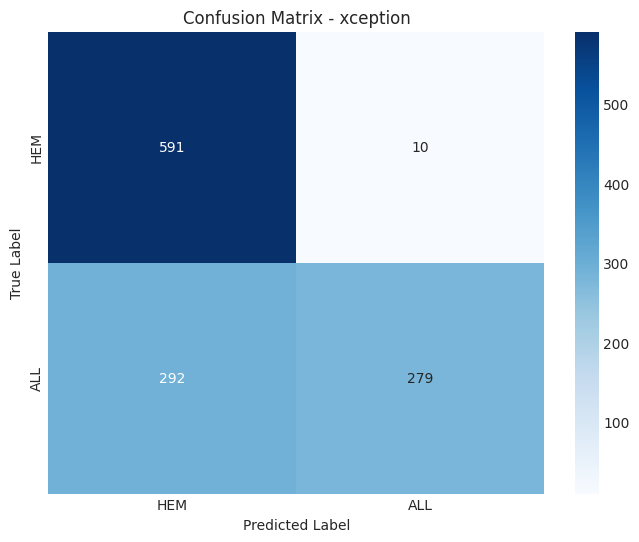

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 15/100


📊 Train -> Loss: 0.4295 | Acc: 0.7537 | F1: 0.7505
📊 Valid -> Loss: 0.2535 | Acc: 0.6834 | F1: 0.6446
📊 Gap: 0.1059 | LR: 0.000009

📍 Epoch 16/100


📊 Train -> Loss: 0.3681 | Acc: 0.7646 | F1: 0.7619
📊 Valid -> Loss: 0.1891 | Acc: 0.7227 | F1: 0.6999
📊 Gap: 0.0619 | LR: 0.000008

📍 Epoch 17/100


📊 Train -> Loss: 0.3401 | Acc: 0.7653 | F1: 0.7629
📊 Valid -> Loss: 0.1876 | Acc: 0.7150 | F1: 0.6902
📊 Gap: 0.0727 | LR: 0.000008

📍 Epoch 18/100


📊 Train -> Loss: 0.3245 | Acc: 0.7576 | F1: 0.7553
📊 Valid -> Loss: 0.1090 | Acc: 0.7201 | F1: 0.6970
📊 Gap: 0.0583 | LR: 0.000007

📍 Epoch 19/100


📊 Train -> Loss: 0.2943 | Acc: 0.7695 | F1: 0.7672
📊 Valid -> Loss: 0.2818 | Acc: 0.6971 | F1: 0.6680
📊 Gap: 0.0992 | LR: 0.000006

📍 Epoch 20/100


📊 Train -> Loss: 0.2744 | Acc: 0.7827 | F1: 0.7809
📊 Valid -> Loss: 0.3187 | Acc: 0.6741 | F1: 0.6338
📊 Gap: 0.1470 | LR: 0.000005

📍 Epoch 21/100


📊 Train -> Loss: 0.2652 | Acc: 0.7893 | F1: 0.7877
📊 Valid -> Loss: 0.6755 | Acc: 0.7346 | F1: 0.7149
📊 Gap: 0.0728 | LR: 0.000005

📍 Epoch 22/100


📊 Train -> Loss: 0.2436 | Acc: 0.7892 | F1: 0.7875
📊 Valid -> Loss: 0.1918 | Acc: 0.6451 | F1: 0.5890
📊 Gap: 0.1985 | LR: 0.000004

📍 Epoch 23/100


📊 Train -> Loss: 0.2329 | Acc: 0.7938 | F1: 0.7925
📊 Valid -> Loss: 0.3463 | Acc: 0.7491 | F1: 0.7323
📊 Gap: 0.0601 | LR: 0.000003
✅ Modelo salvo! F1: 0.7323 | Acc: 0.7491 | Gap: 0.0601


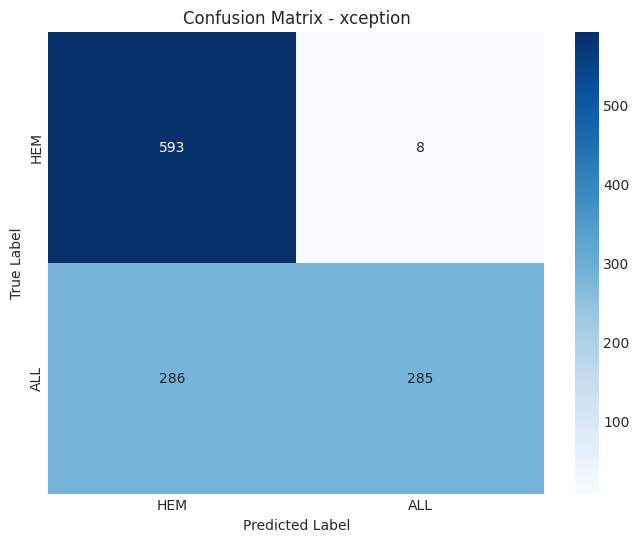

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 24/100


📊 Train -> Loss: 0.2335 | Acc: 0.7999 | F1: 0.7987
📊 Valid -> Loss: 0.1823 | Acc: 0.7253 | F1: 0.7022
📊 Gap: 0.0964 | LR: 0.000003

📍 Epoch 25/100


📊 Train -> Loss: 0.2228 | Acc: 0.8007 | F1: 0.7993
📊 Valid -> Loss: 0.3370 | Acc: 0.7184 | F1: 0.6926
📊 Gap: 0.1067 | LR: 0.000002

📍 Epoch 26/100


📊 Train -> Loss: 0.2132 | Acc: 0.8163 | F1: 0.8152
📊 Valid -> Loss: 0.3367 | Acc: 0.6826 | F1: 0.6448
📊 Gap: 0.1704 | LR: 0.000002

📍 Epoch 27/100


📊 Train -> Loss: 0.2155 | Acc: 0.8065 | F1: 0.8054
📊 Valid -> Loss: 0.9471 | Acc: 0.7235 | F1: 0.7010
📊 Gap: 0.1044 | LR: 0.000001

📍 Epoch 28/100


...

📊 Train -> Loss: 0.1918 | Acc: 0.8116 | F1: 0.8103
📊 Valid -> Loss: 2.7416 | Acc: 0.6485 | F1: 0.5941
📊 Gap: 0.2162 | LR: 0.000010

📍 Epoch 37/100


📊 Train -> Loss: 0.1744 | Acc: 0.8171 | F1: 0.8157
📊 Valid -> Loss: 1.6708 | Acc: 0.6869 | F1: 0.6511
📊 Gap: 0.1646 | LR: 0.000009

📍 Epoch 38/100


📊 Train -> Loss: 0.1698 | Acc: 0.8154 | F1: 0.8143
📊 Valid -> Loss: 2.1451 | Acc: 0.7423 | F1: 0.7246
📊 Gap: 0.0897 | LR: 0.000009

📍 Epoch 39/100


📊 Train -> Loss: 0.1720 | Acc: 0.8235 | F1: 0.8226
📊 Valid -> Loss: 3.1290 | Acc: 0.7295 | F1: 0.7073
📊 Gap: 0.1153 | LR: 0.000009

📍 Epoch 40/100


📊 Train -> Loss: 0.1584 | Acc: 0.8248 | F1: 0.8238
📊 Valid -> Loss: 1.2496 | Acc: 0.7816 | F1: 0.7724
📊 Gap: 0.0514 | LR: 0.000009
✅ Modelo salvo! F1: 0.7724 | Acc: 0.7816 | Gap: 0.0514


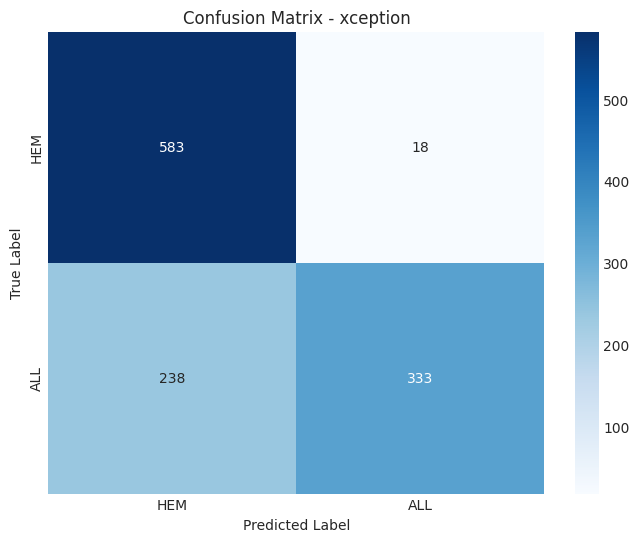

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 41/100


📊 Train -> Loss: 0.1564 | Acc: 0.8334 | F1: 0.8324
📊 Valid -> Loss: 8.0131 | Acc: 0.7227 | F1: 0.6993
📊 Gap: 0.1331 | LR: 0.000008

📍 Epoch 42/100


📊 Train -> Loss: 0.1460 | Acc: 0.8441 | F1: 0.8434
📊 Valid -> Loss: 4.1952 | Acc: 0.7090 | F1: 0.6818
📊 Gap: 0.1616 | LR: 0.000008

📍 Epoch 43/100


📊 Train -> Loss: 0.1452 | Acc: 0.8405 | F1: 0.8399
📊 Valid -> Loss: 1.7054 | Acc: 0.7841 | F1: 0.7743
📊 Gap: 0.0655 | LR: 0.000008
✅ Modelo salvo! F1: 0.7743 | Acc: 0.7841 | Gap: 0.0655


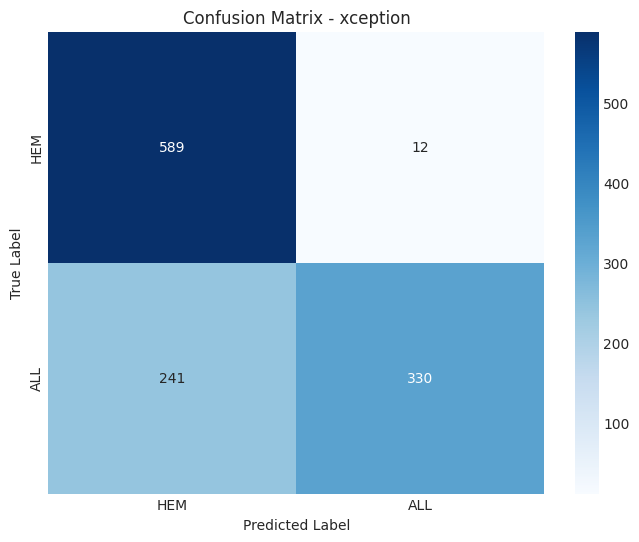

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 44/100


📊 Train -> Loss: 0.1387 | Acc: 0.8518 | F1: 0.8513
📊 Valid -> Loss: 2.4444 | Acc: 0.7773 | F1: 0.7656
📊 Gap: 0.0858 | LR: 0.000008

📍 Epoch 45/100


📊 Train -> Loss: 0.1508 | Acc: 0.8487 | F1: 0.8479
📊 Valid -> Loss: 9.4884 | Acc: 0.7807 | F1: 0.7722
📊 Gap: 0.0757 | LR: 0.000007

📍 Epoch 46/100


📊 Train -> Loss: 0.1323 | Acc: 0.8594 | F1: 0.8588
📊 Valid -> Loss: 6.7557 | Acc: 0.7628 | F1: 0.7516
📊 Gap: 0.1072 | LR: 0.000007

📍 Epoch 47/100


📊 Train -> Loss: 0.1461 | Acc: 0.8562 | F1: 0.8557
📊 Valid -> Loss: 3.8436 | Acc: 0.8404 | F1: 0.8382
📊 Gap: 0.0175 | LR: 0.000007
✅ Modelo salvo! F1: 0.8382 | Acc: 0.8404 | Gap: 0.0175


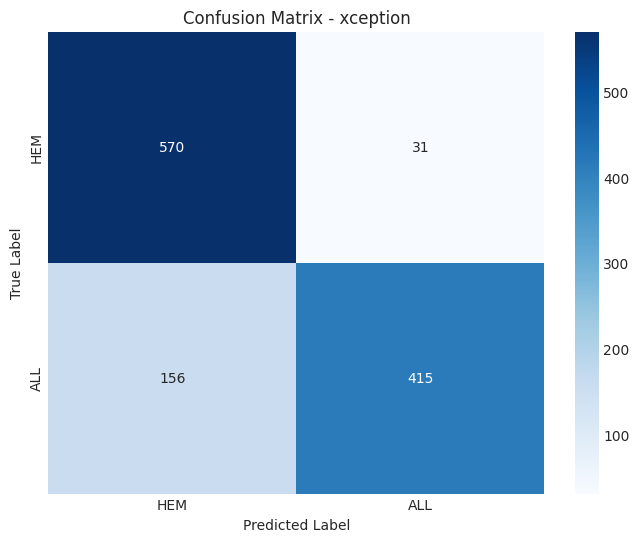

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 48/100


📊 Train -> Loss: 0.1314 | Acc: 0.8686 | F1: 0.8683
📊 Valid -> Loss: 9.6676 | Acc: 0.7790 | F1: 0.7685
📊 Gap: 0.0998 | LR: 0.000006

📍 Epoch 49/100


📊 Train -> Loss: 0.1238 | Acc: 0.8720 | F1: 0.8716
📊 Valid -> Loss: 4.4776 | Acc: 0.8003 | F1: 0.7921
📊 Gap: 0.0795 | LR: 0.000006

📍 Epoch 50/100


📊 Train -> Loss: 0.1244 | Acc: 0.8828 | F1: 0.8825
📊 Valid -> Loss: 6.1695 | Acc: 0.7901 | F1: 0.7805
📊 Gap: 0.1020 | LR: 0.000005

📍 Epoch 51/100


📊 Train -> Loss: 0.1231 | Acc: 0.8876 | F1: 0.8874
📊 Valid -> Loss: 5.6691 | Acc: 0.8285 | F1: 0.8245
📊 Gap: 0.0630 | LR: 0.000005

📍 Epoch 52/100


...

📊 Train -> Loss: 0.0953 | Acc: 0.8968 | F1: 0.8966
📊 Valid -> Loss: 6.0678 | Acc: 0.8063 | F1: 0.7994
📊 Gap: 0.0972 | LR: 0.000004

📍 Epoch 56/100


📊 Train -> Loss: 0.1019 | Acc: 0.8970 | F1: 0.8968
📊 Valid -> Loss: 7.0533 | Acc: 0.8242 | F1: 0.8187
📊 Gap: 0.0781 | LR: 0.000003

📍 Epoch 57/100


📊 Train -> Loss: 0.0997 | Acc: 0.9049 | F1: 0.9048
📊 Valid -> Loss: 4.0597 | Acc: 0.8046 | F1: 0.7971
📊 Gap: 0.1077 | LR: 0.000003

📍 Epoch 58/100


📊 Train -> Loss: 0.1146 | Acc: 0.9053 | F1: 0.9053
📊 Valid -> Loss: 6.7127 | Acc: 0.7645 | F1: 0.7501
📊 Gap: 0.1552 | LR: 0.000003

📍 Epoch 59/100


📊 Train -> Loss: 0.1038 | Acc: 0.9088 | F1: 0.9087
📊 Valid -> Loss: 1.4090 | Acc: 0.8584 | F1: 0.8559
📊 Gap: 0.0529 | LR: 0.000003
✅ Modelo salvo! F1: 0.8559 | Acc: 0.8584 | Gap: 0.0529


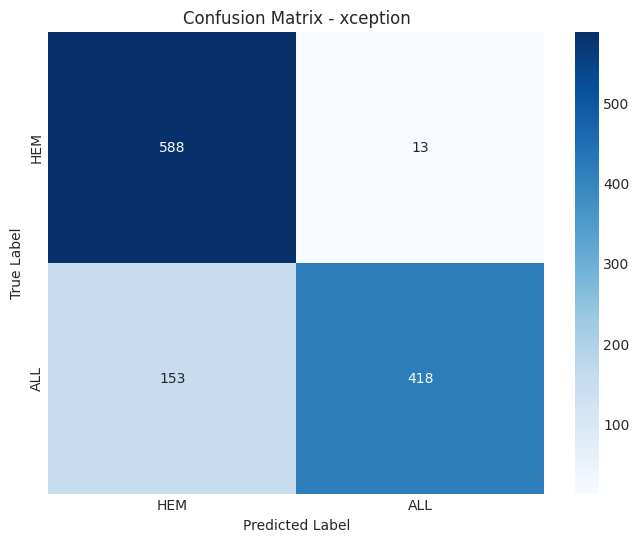

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 60/100


📊 Train -> Loss: 0.1040 | Acc: 0.9074 | F1: 0.9073
📊 Valid -> Loss: 2.1175 | Acc: 0.8259 | F1: 0.8203
📊 Gap: 0.0869 | LR: 0.000002

📍 Epoch 61/100


📊 Train -> Loss: 0.1079 | Acc: 0.9096 | F1: 0.9095
📊 Valid -> Loss: 1.6135 | Acc: 0.8208 | F1: 0.8148
📊 Gap: 0.0947 | LR: 0.000002

📍 Epoch 62/100


📊 Train -> Loss: 0.0976 | Acc: 0.9121 | F1: 0.9120
📊 Valid -> Loss: 1.3766 | Acc: 0.8157 | F1: 0.8094
📊 Gap: 0.1026 | LR: 0.000002

📍 Epoch 63/100


📊 Train -> Loss: 0.1056 | Acc: 0.9155 | F1: 0.9154
📊 Valid -> Loss: 1.7049 | Acc: 0.6664 | F1: 0.6220
📊 Gap: 0.2934 | LR: 0.000002

📍 Epoch 64/100


...

📊 Train -> Loss: 0.0928 | Acc: 0.9231 | F1: 0.9231
📊 Valid -> Loss: 8.4795 | Acc: 0.7918 | F1: 0.7818
📊 Gap: 0.1413 | LR: 0.000001

📍 Epoch 67/100


📊 Train -> Loss: 0.0968 | Acc: 0.9232 | F1: 0.9232
📊 Valid -> Loss: 1.6868 | Acc: 0.8404 | F1: 0.8362
📊 Gap: 0.0869 | LR: 0.000001

📍 Epoch 68/100


📊 Train -> Loss: 0.0958 | Acc: 0.9234 | F1: 0.9234
📊 Valid -> Loss: 6.8367 | Acc: 0.8225 | F1: 0.8168
📊 Gap: 0.1065 | LR: 0.000001

📍 Epoch 69/100


📊 Train -> Loss: 0.0952 | Acc: 0.9225 | F1: 0.9225
📊 Valid -> Loss: 7.4089 | Acc: 0.8114 | F1: 0.8041
📊 Gap: 0.1183 | LR: 0.000001

📍 Epoch 70/100


📊 Train -> Loss: 0.0978 | Acc: 0.9200 | F1: 0.9199
📊 Valid -> Loss: 3.2771 | Acc: 0.8669 | F1: 0.8645
📊 Gap: 0.0555 | LR: 0.000010
✅ Modelo salvo! F1: 0.8645 | Acc: 0.8669 | Gap: 0.0555


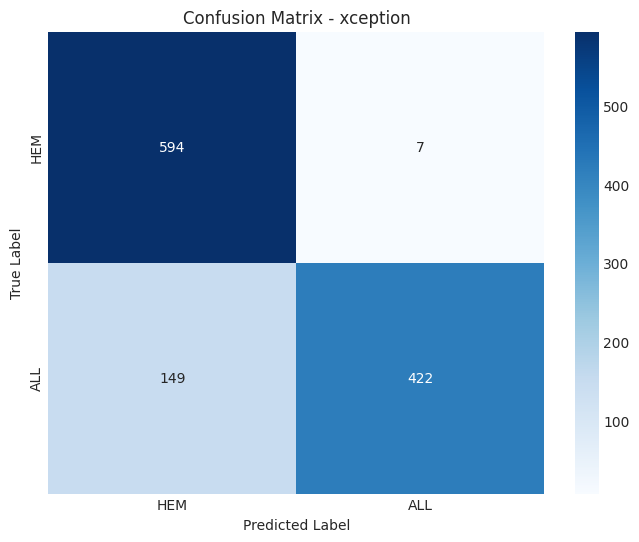

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 71/100


📊 Train -> Loss: 0.1012 | Acc: 0.9061 | F1: 0.9060
📊 Valid -> Loss: 0.5713 | Acc: 0.7867 | F1: 0.7755
📊 Gap: 0.1305 | LR: 0.000010

📍 Epoch 72/100


📊 Train -> Loss: 0.1145 | Acc: 0.9062 | F1: 0.9061
📊 Valid -> Loss: 2.6302 | Acc: 0.8311 | F1: 0.8260
📊 Gap: 0.0801 | LR: 0.000010

📍 Epoch 73/100


📊 Train -> Loss: 0.1152 | Acc: 0.8979 | F1: 0.8977
📊 Valid -> Loss: 0.6921 | Acc: 0.7338 | F1: 0.7118
📊 Gap: 0.1859 | LR: 0.000010

📍 Epoch 74/100


📊 Train -> Loss: 0.0940 | Acc: 0.9043 | F1: 0.9042
📊 Valid -> Loss: 0.6065 | Acc: 0.7159 | F1: 0.6889
📊 Gap: 0.2152 | LR: 0.000010

📍 Epoch 75/100


📊 Train -> Loss: 0.1009 | Acc: 0.9082 | F1: 0.9081
📊 Valid -> Loss: 1.2002 | Acc: 0.7850 | F1: 0.7734
📊 Gap: 0.1348 | LR: 0.000010

📍 Epoch 76/100


📊 Train -> Loss: 0.1035 | Acc: 0.9053 | F1: 0.9051
📊 Valid -> Loss: 1.7215 | Acc: 0.6101 | F1: 0.5337
📊 Gap: 0.3714 | LR: 0.000010

📍 Epoch 77/100


📊 Train -> Loss: 0.0873 | Acc: 0.9084 | F1: 0.9083
📊 Valid -> Loss: 2.4449 | Acc: 0.6647 | F1: 0.6201
📊 Gap: 0.2882 | LR: 0.000010

📍 Epoch 78/100


📊 Train -> Loss: 0.0835 | Acc: 0.9137 | F1: 0.9136
📊 Valid -> Loss: 0.7217 | Acc: 0.7227 | F1: 0.6971
📊 Gap: 0.2166 | LR: 0.000010

📍 Epoch 79/100


📊 Train -> Loss: 0.0777 | Acc: 0.9121 | F1: 0.9120
📊 Valid -> Loss: 0.4020 | Acc: 0.8899 | F1: 0.8889
📊 Gap: 0.0231 | LR: 0.000010
✅ Modelo salvo! F1: 0.8889 | Acc: 0.8899 | Gap: 0.0231


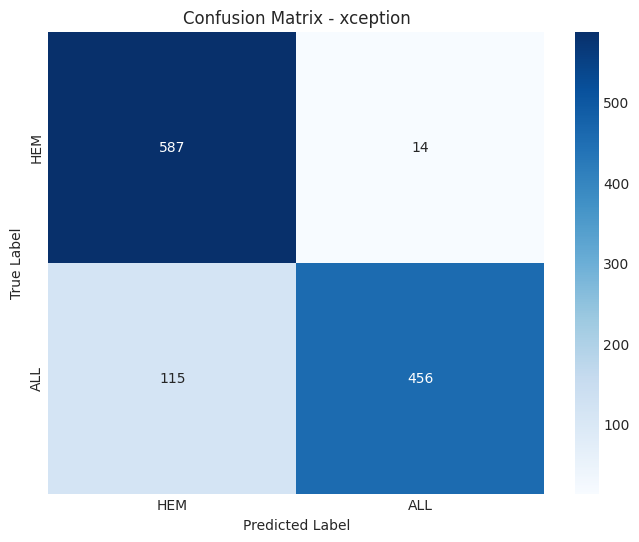

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 80/100


📊 Train -> Loss: 0.0790 | Acc: 0.9172 | F1: 0.9172
📊 Valid -> Loss: 0.9783 | Acc: 0.8439 | F1: 0.8401
📊 Gap: 0.0771 | LR: 0.000010

📍 Epoch 81/100


📊 Train -> Loss: 0.0869 | Acc: 0.9282 | F1: 0.9281
📊 Valid -> Loss: 0.8325 | Acc: 0.7372 | F1: 0.7158
📊 Gap: 0.2124 | LR: 0.000010

📍 Epoch 82/100


📊 Train -> Loss: 0.0701 | Acc: 0.9229 | F1: 0.9228
📊 Valid -> Loss: 2.3038 | Acc: 0.8524 | F1: 0.8489
📊 Gap: 0.0739 | LR: 0.000010

📍 Epoch 83/100


📊 Train -> Loss: 0.0801 | Acc: 0.9274 | F1: 0.9273
📊 Valid -> Loss: 1.4272 | Acc: 0.7142 | F1: 0.6867
📊 Gap: 0.2406 | LR: 0.000009

📍 Epoch 84/100


...

📊 Train -> Loss: 0.0782 | Acc: 0.9251 | F1: 0.9251
📊 Valid -> Loss: 0.9200 | Acc: 0.7329 | F1: 0.7107
📊 Gap: 0.2144 | LR: 0.000009

📍 Epoch 86/100


📊 Train -> Loss: 0.0757 | Acc: 0.9382 | F1: 0.9382
📊 Valid -> Loss: 0.8492 | Acc: 0.8601 | F1: 0.8573
📊 Gap: 0.0809 | LR: 0.000009

📍 Epoch 87/100


📊 Train -> Loss: 0.0697 | Acc: 0.9392 | F1: 0.9391
📊 Valid -> Loss: 0.1491 | Acc: 0.7176 | F1: 0.6908
📊 Gap: 0.2484 | LR: 0.000009

📍 Epoch 88/100


📊 Train -> Loss: 0.0623 | Acc: 0.9312 | F1: 0.9312
📊 Valid -> Loss: 0.3497 | Acc: 0.8797 | F1: 0.8781
📊 Gap: 0.0531 | LR: 0.000009

📍 Epoch 89/100


📊 Train -> Loss: 0.0592 | Acc: 0.9383 | F1: 0.9383
📊 Valid -> Loss: 0.0677 | Acc: 0.8942 | F1: 0.8933
📊 Gap: 0.0450 | LR: 0.000009
✅ Modelo salvo! F1: 0.8933 | Acc: 0.8942 | Gap: 0.0450


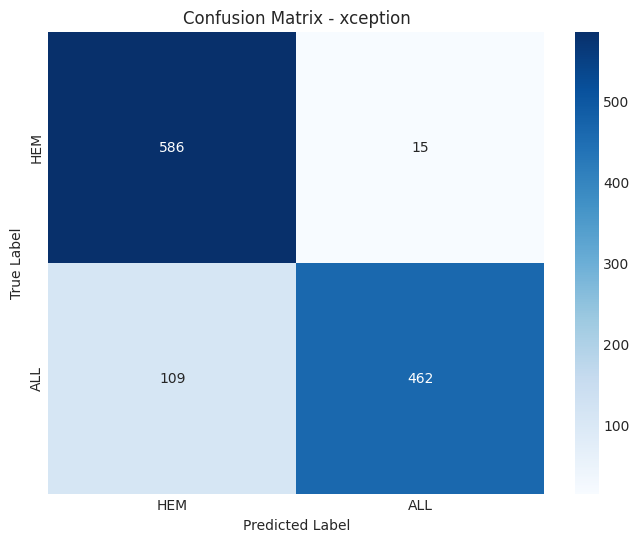

📊 Matriz de confusão salva em: models/vgg_xception/xception_confusion_matrix.png

📍 Epoch 90/100


📊 Train -> Loss: 0.0743 | Acc: 0.9400 | F1: 0.9400
📊 Valid -> Loss: 0.3125 | Acc: 0.8567 | F1: 0.8536
📊 Gap: 0.0864 | LR: 0.000009

📍 Epoch 91/100


📊 Train -> Loss: 0.0829 | Acc: 0.9368 | F1: 0.9368
📊 Valid -> Loss: 0.2401 | Acc: 0.7005 | F1: 0.6683
📊 Gap: 0.2685 | LR: 0.000009

📍 Epoch 92/100


📊 Train -> Loss: 0.0763 | Acc: 0.9385 | F1: 0.9384
📊 Valid -> Loss: 0.4287 | Acc: 0.7730 | F1: 0.7596
📊 Gap: 0.1789 | LR: 0.000008

📍 Epoch 93/100


📊 Train -> Loss: 0.0759 | Acc: 0.9421 | F1: 0.9421
📊 Valid -> Loss: 1.5358 | Acc: 0.7253 | F1: 0.7003
📊 Gap: 0.2417 | LR: 0.000008

📍 Epoch 94/100


...

📊 Train -> Loss: 0.0694 | Acc: 0.9443 | F1: 0.9442
📊 Valid -> Loss: 0.0808 | Acc: 0.7850 | F1: 0.7732
📊 Gap: 0.1711 | LR: 0.000008

📍 Epoch 97/100


📊 Train -> Loss: 0.0705 | Acc: 0.9488 | F1: 0.9488
📊 Valid -> Loss: 0.4708 | Acc: 0.7543 | F1: 0.7373
📊 Gap: 0.2115 | LR: 0.000008

📍 Epoch 98/100


📊 Train -> Loss: 0.0645 | Acc: 0.9499 | F1: 0.9499
📊 Valid -> Loss: 0.0418 | Acc: 0.8370 | F1: 0.8321
📊 Gap: 0.1178 | LR: 0.000008

📍 Epoch 99/100


📊 Train -> Loss: 0.0650 | Acc: 0.9525 | F1: 0.9525
📊 Valid -> Loss: 0.0534 | Acc: 0.7577 | F1: 0.7410
📊 Gap: 0.2115 | LR: 0.000007

📍 Epoch 100/100


📊 Train -> Loss: 0.0528 | Acc: 0.9520 | F1: 0.9520
📊 Valid -> Loss: 0.0680 | Acc: 0.7935 | F1: 0.7834
📊 Gap: 0.1686 | LR: 0.000007

TREINAMENTO CONCLUÍDO - XCEPTION
Melhor F1-Score: 0.8933 (Época 89)
Melhor Accuracy: 0.8942


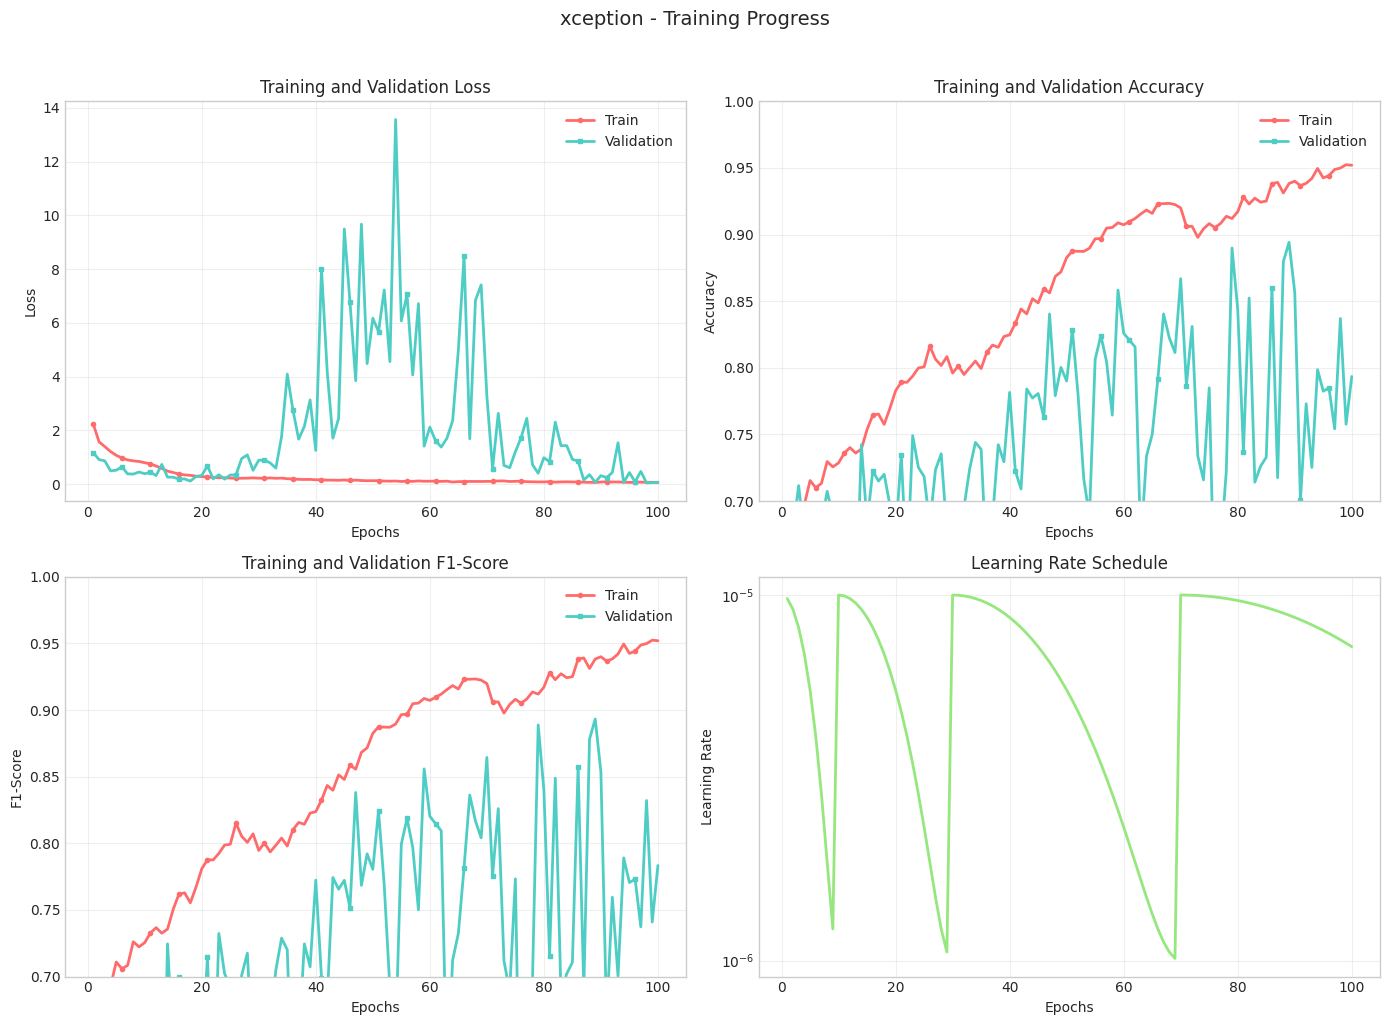

📊 Gráfico salvo em: models/vgg_xception/xception_training_curves.png
📁 Histórico salvo em: models/vgg_xception/xception_history.pkl

RESULTADOS FINAIS:
vgg16: F1-Score = 0.8683, Accuracy = 0.8695, BestEpoch = 33, ckpt: vgg16_best.pt
vgg19: F1-Score = 0.5001, Accuracy = 0.5887, BestEpoch = 2, ckpt: vgg19_best.pt
xception: F1-Score = 0.8933, Accuracy = 0.8942, BestEpoch = 89, ckpt: xception_best.pt


In [13]:
def main():
    print("Iniciando treinamento de modelos CNN...")
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    
    # Definir modelos para treinar
    models = ['vgg16', 'vgg19', 'xception']  # ou use CNN_MODELS se estiver definido
    
    results = {}  # ex.: {"vgg16": {"f1": 0.93, "accuracy": 0.94, "best_epoch": 18, "model_path": "..."}}
    for model_name in models:
        try:
            ret = train_model(model_name)  # pode retornar float, tuple ou dict

            # Normalizar saída em um dict de métricas
            metrics = {}
            if isinstance(ret, dict):
                # F1 (obrigatório)
                if "f1" in ret:
                    metrics["f1"] = float(ret["f1"])
                elif "F1" in ret:
                    metrics["f1"] = float(ret["F1"])
                else:
                    metrics["f1"] = 0.0

                # Demais métricas opcionais
                if "accuracy" in ret:
                    metrics["accuracy"] = float(ret["accuracy"])
                if "acc" in ret:
                    metrics["accuracy"] = float(ret["acc"])
                if "precision" in ret:
                    metrics["precision"] = float(ret["precision"])
                if "recall" in ret:
                    metrics["recall"] = float(ret["recall"])
                if "auc" in ret:
                    metrics["auc"] = float(ret["auc"])
                if "best_epoch" in ret:
                    metrics["best_epoch"] = int(ret["best_epoch"])
                if "model_path" in ret and ret["model_path"]:
                    metrics["model_path"] = ret["model_path"]

            elif isinstance(ret, tuple):
                # Supondo (f1, acc, best_epoch) como mais comum
                metrics["f1"] = float(ret[0]) if len(ret) > 0 else 0.0
                if len(ret) > 1 and ret[1] is not None:
                    metrics["accuracy"] = float(ret[1])
                if len(ret) > 2 and ret[2] is not None:
                    metrics["best_epoch"] = int(ret[2])

            else:
                # Número simples (float/int) → só F1
                metrics["f1"] = float(ret)

            results[model_name] = metrics

            # Limpar memória
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"Erro ao treinar {model_name}: {e}")
            results[model_name] = {"f1": 0.0}
    
    print("\n" + "="*50)
    print("RESULTADOS FINAIS:")
    for name, m in results.items():
        f1 = m.get("f1", 0.0)
        line = f"{name}: F1-Score = {f1:.4f}"
        if "accuracy" in m:
            line += f", Accuracy = {m['accuracy']:.4f}"
        if "precision" in m:
            line += f", Precision = {m['precision']:.4f}"
        if "recall" in m:
            line += f", Recall = {m['recall']:.4f}"
        if "auc" in m:
            line += f", AUC = {m['auc']:.4f}"
        if "best_epoch" in m:
            line += f", BestEpoch = {m['best_epoch']}"
        if m.get("model_path"):
            line += f", ckpt: {os.path.basename(m['model_path'])}"
        print(line)
    
    # Salvar resumo estruturado
    with open(os.path.join(SAVE_DIR, 'cnn_training_results.pkl'), 'wb') as f:
        pickle.dump(results, f)

if __name__ == "__main__":
    main()
